## Explore how to ensure my density plots for phi, dt align with Baillard - critical for comparing the two in a meaningful way
We will load processed data and adjust plotting scripts until we get results that are consistent with Christian's 2018 poster

In [1]:
# Dependencies

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy.core.utcdatetime import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.event import read_events
import os
import sys
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add local swspy directory to path (before other imports)
swspy_local_path = os.path.abspath('../swspy')
if swspy_local_path not in sys.path:
    sys.path.insert(0, swspy_local_path)

# Import swspy from local directory
import swspy

# Add scripts directory to path for custom modules
sys.path.append('.')
from get_all_traces import get_station_traces_batch
from splitting_functions import *
from teanby_clustering import *

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")
print(f"ObsPy version: {obspy.__version__}")
print(f"SWSPy available: {'Yes' if 'swspy' in sys.modules else 'No'}")
print(f"SWSPy location: {swspy.__file__}")

mtspec not available, using ObsPy PPSD method
Libraries imported successfully
ObsPy version: 1.4.2
SWSPy available: Yes
SWSPy location: /Users/mhemmett/Seismology/axial-splitting-ml/swspy/swspy/__init__.py


In [2]:
import sws_methods as swm

In [28]:
def plot_movehisto2d(x,y,
                x_label='X',y_label='Y',title='',ax=None,vmax=None,
                **movehisto2d_kwargs):
    """
    Function made to plot an histo2d but using a moving window in both directions, this ensure better
    consistency between neighbor bins. 
    The histogram can also work when data is an obspy.UTCDateTime array, then the x_start and x_end must
    be given in UTCDateTime as well and the x_width should be given in seconds.
    UTCDatetime are converted to timestamps (seconds since 1970)
    
    Inputs
    ------
        x,y: np.array: arrays containing the data to apply histogram on (x can be UTCDateTime)
        x_width,y_width: float: width of the bins (in seconds for UTCDateTime)
        [x,y]_[start,end]: float: start and end for histogram edges
        [x,y]_over: float in [0,1]: overlap for windows [1 = full overlap]
        flag_y_norm: Boolean: True to normalize by the maximum in each column
        flag_resample: Boolean: Enable resampling to uniform grid (required for smoothing)
        flag_filter: Boolean: Enable Gaussian filtering (requires flag_resample=True)
        x_filter_per, y_filter_per: float in [0,100]: width percentage for smoothing
        filter_mode: str or list: 'nearest' or 'wrap' for edge handling
        [x,y]_label: str
        
    Ouputs
    ------
        ax, im, X, Y, Z, x_bins, x_diffs
        
    Comments:
    ---------
        Uses Baillard's movehisto2d_bin for resampling and filtering
        
    UsedIn
    ------
        SWSCat.plot_movehisto2d_time, wrapper functions
    """
    
    ### Check if is made of UTCDateTimes
    
    time_flag=False
    if isinstance(x[0],UTCDateTime):
        time_flag=True
        print('X is in UTCDateTime')
        if movehisto2d_kwargs.get('x_mode','window')=='window':
            print('Remember width should be given in seconds, otherwise memory error')
    
    ### Modify x_start and x_end, and x if x is time and convert to timestamps
    x_start=movehisto2d_kwargs.get('x_start',None)
    x_end=movehisto2d_kwargs.get('x_end',None)
    y_start=movehisto2d_kwargs.get('y_start',None)
    y_end=movehisto2d_kwargs.get('y_end',None)
    
    if time_flag:
        if (x_start is not None) & (not isinstance(x_start,UTCDateTime)):
            raise ValueError('x_start must be given in obspy.UTCDateTime')
        if (x_end is not None) & (not isinstance(x_end,UTCDateTime)):
            raise ValueError('x_end must be given in obspy.UTCDateTime')
        x=np.array([value.timestamp for value in x]) # (seconds since 1970-01-01T00:00:00)
        x_start=x_start.timestamp if x_start is not None else None
        x_end=x_end.timestamp if x_end is not None else None
        movehisto2d_kwargs['x_start']=x_start
        movehisto2d_kwargs['x_end']=x_end

    ### Bin the data (smoothing handled inside movehisto2d_bin via resampling + filtering)
    
    (X,Y,Z,x_bins,x_diffs)=swm.movehisto2d_bin(x,y,**movehisto2d_kwargs)
    
        # Added to fix edge artifacts issues - bins on edges have less data, highly sensitive to outliers
       # Drop first and last x-bins (edge time windows) before plotting
    if X.shape[1] > 2:          # only if we have at least 3 columns
        X = X[:, 1:-1]
        Y = Y[:, 1:-1]
        Z = Z[:, 1:-1]
        x_bins = x_bins[1:-1]
        x_diffs = x_diffs[1:-1]

        
    ########################
    #### Start plotting ####

    #### Grid spec
    
    bottom=0.15 if time_flag else 0.1
    
    ### Checks
    
    if ax is None:
        fig,ax = plt.subplots(gridspec_kw={'bottom':bottom,'left':0.15})
        
    if time_flag:
        X=np.array(swm.timestamp2matplotlib(X.ravel())).reshape(X.shape) # transform for plotting
        x_bins=swm.timestamp2matplotlib(x_bins)
        plt.setp( ax.xaxis.get_majorticklabels(), rotation=30 ,ha='right')
        ax.set_xlim(swm.timestamp2matplotlib([x_start,x_end]))
    else:
        ax.set_xlim([x_start,x_end])
       
    (Xm,Ym)=swm.XY2XY_pcolormesh(X,Y) # To ensure Pcolormesh will be centered on bins

    #im=ax.pcolormesh(X,Y,Z,cmap=plt.cm.get_cmap('jet'),rasterized=True)
    im=ax.pcolormesh(Xm,Ym,Z,cmap=plt.cm.get_cmap('inferno'),rasterized=True,vmax=vmax)
    
    ax.set_ylim([y_start,y_end])
    
    ax.set_aspect('auto')
    if time_flag:
        ax.xaxis_date()
            
    ### Cosmetic
    
    ax.set_ylabel(y_label) 
    if not time_flag:
        ax.set_xlabel(x_label) 
   
    ###### Return
    
    return (ax,im,X,Y,Z,x_bins,x_diffs)

In [29]:
def plot_fast_direction_rose_eruption_comparison(results_df, eruption_time=None, 
                                                  title_prefix="Fast Direction Distribution",
                                                  nbins=36, figsize=(16, 7), color='steelblue',
                                                  edgecolor='black', linewidth=0.5,
                                                  time_column='event_datetime'):
    """
    Create side-by-side 360° rose plots comparing fast directions before and after eruption.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with splitting results containing 'phi' and time columns
    eruption_time : UTCDateTime or str
        Time of eruption onset (default: 2015-04-24T06:00:00)
    title_prefix : str
        Prefix for plot titles
    nbins : int
        Number of angular bins (default 36 = 10° bins for 360°)
    figsize : tuple
        Figure size (width, height) for combined plot
    color : str
        Color for the histogram bars
    edgecolor : str
        Color for bar edges
    linewidth : float
        Width of bar edges
    time_column : str
        Name of the time column in results_df (default 'event_datetime')
    """
    if eruption_time is None:
        eruption_time = UTCDateTime(2015, 4, 24, 6)
    elif not isinstance(eruption_time, UTCDateTime):
        eruption_time = UTCDateTime(eruption_time)
    
    # Convert time column to UTCDateTime for comparison
    df_time = results_df[time_column].apply(lambda x: UTCDateTime(x) if not isinstance(x, UTCDateTime) else x)
    results_before = results_df[df_time < eruption_time]
    results_after = results_df[df_time >= eruption_time]
    
    # Create figure with two subplots
    fig = plt.figure(figsize=figsize)
    
    # Before eruption plot (left)
    ax1 = fig.add_subplot(121, projection='polar')
    plot_rose_subplot(results_before, ax1, f"{title_prefix}\nBefore Eruption", 
                      nbins, color, edgecolor, linewidth)
    
    # After eruption plot (right)
    ax2 = fig.add_subplot(122, projection='polar')
    plot_rose_subplot(results_after, ax2, f"{title_prefix}\nAfter Eruption", 
                      nbins, color, edgecolor, linewidth)
    
    plt.tight_layout()
    return fig, (ax1, ax2), (results_before, results_after)


def plot_rose_subplot(results_df, ax, title, nbins, color, edgecolor, linewidth):
    """
    Helper function to plot rose diagram on a given axis.
    """
    if len(results_df) == 0:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=14)
        return
    
    fast_directions = []
    for phi in results_df['phi'].values:  # in degrees (-90 to +90)
        # Convert to 0-360 range and add 180° symmetry
        phi_0_180 = phi + 90  # Convert to 0-180 range
        phi_rad_1 = np.deg2rad(phi_0_180)
        phi_rad_2 = np.deg2rad(phi_0_180 + 180)  # Add 180° symmetric value
        fast_directions.append(phi_rad_1)
        fast_directions.append(phi_rad_2)
    
    fast_directions = np.array(fast_directions)
    
    # Create histogram bins (0 to 2π for 0° to 360°)
    bins = np.linspace(0, 2*np.pi, nbins + 1)
    
    # Calculate histogram
    counts, bin_edges = np.histogram(fast_directions, bins=bins)
    
    # Calculate bin centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Width of each bar
    width = 2 * np.pi / nbins
    
    # Create the rose plot
    bars = ax.bar(bin_centers, counts, width=width, bottom=0.0,
                   color=color, edgecolor=edgecolor, linewidth=linewidth, alpha=0.7)
    
    # Set theta direction (clockwise from North)
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    
    # Set radial ticks
    ax.set_rlabel_position(45)
    
    # Add degree labels for full 360°
    tick_labels = ['0°', '45°', '90°', '135°', '180°', '225°', '270°', '315°']
    tick_positions = np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315])
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    
    # Adjust y-limit
    max_count = counts.max()
    ax.set_ylim(0, max_count * 1.2)
    
    # Add title with statistics
    n_measurements = len(fast_directions) // 2  # Divide by 2 since we doubled for symmetry
    # Calculate circular mean
    original_directions = np.deg2rad(results_df['phi'].values)
    mean_direction = np.rad2deg(np.arctan2(np.sin(original_directions).sum(), 
                                           np.cos(original_directions).sum()))
    
    title_text = f"{title}\nN = {n_measurements}, Mean = {mean_direction:.1f}°"
    ax.set_title(title_text, va='bottom', fontsize=12, fontweight='bold', pad=20)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.5)

In [30]:
def plot_dt_timeseries_movehisto(results_df, time_column='event_datetime',
                                  x_width=5*24*3600, x_overlap=0.95,
                                  y_width=2, y_overlap=0.9,
                                  sampling_rate=200.0,
                                  figsize=(14, 6),
                                  station='AXAS2',
                                  flag_smooth=True,
                                  x_filter_per=10,
                                  y_filter_per=10):
    """
    Plot delay time (dt) over time using moving window 2D histogram with Baillard-style smoothing.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with splitting results
    time_column : str
        Name of time column (default 'event_datetime')
    x_width : float
        Width of time window in seconds (default 5 days = 5*24*3600)
    x_overlap : float
        Overlap fraction for time windows (0.95 = 95% overlap)
    y_width : float
        Bin width for dt in samples
    y_overlap : float
        Overlap for y-direction
    sampling_rate : float
        Sampling rate in Hz (default 200 Hz)
    figsize : tuple
        Figure size
    station : str
        Station name for title
    flag_smooth : bool
        Apply Baillard-style smoothing via resampling (default True)
    x_filter_per : float
        Gaussian filter width percentage in time direction (default 10)
    y_filter_per : float
        Gaussian filter width percentage in y direction (default 10)
    """
    import sws_methods as swm
    # Extract data
    df = results_df.copy()
    times = pd.to_datetime(df[time_column])
    dt_samples = df['dt'].values * sampling_rate
    
    # Convert to UTCDateTime for movehisto2d
    x = np.array([UTCDateTime(t) for t in times])
    y = dt_samples
    
    # Set time range
    x_start = UTCDateTime(times.min())
    x_end = UTCDateTime(times.max())
    y_start = 0
    y_end = 30

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot with Baillard-style resampling and smoothing
    (ax, im, X, Y, Z, x_bins, x_diffs) = plot_movehisto2d(
        x, y,
        x_label='Date',
        y_label='Delay Time δt (samples)',
        ax=ax,
        x_width=x_width,
        x_start=x_start,
        x_end=x_end,
        y_start=y_start,
        y_end=y_end,
        x_over=x_overlap,
        y_over=y_overlap,
        y_width=y_width,
        flag_y_norm=True,  # Normalize by column (Baillard's norm_y)
        flag_resample=flag_smooth,  # Enable resampling for smoothing
        flag_filter=flag_smooth,  # Enable Gaussian filtering after resampling
        x_filter_per=x_filter_per,  # Smoothing percentage in time
        y_filter_per=y_filter_per,  # Smoothing percentage in y
        filter_mode='nearest',  # Non-cyclic edge handling
        vmax=None
    )
    
    # Add eruption line
    eruption_time = UTCDateTime(2015, 4, 24, 6)
    ax.axvline(eruption_time.matplotlib_date, color='white', 
               linestyle='--', alpha=0.7, linewidth=2)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Normalized Density', fontsize=10)
    
    # Add title with statistics
    dt_mean = df['dt'].mean()
    dt_std = df['dt'].std()
    title = (f"Delay Time Time Series - Station {station}\n"
             f"N = {len(df)} events | "
             f"δt: {dt_mean:.3f} ± {dt_std:.3f} s "
             f"({dt_mean*sampling_rate:.1f} ± {dt_std*sampling_rate:.1f} samples)")
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax


def plot_phi_timeseries_movehisto(results_df, time_column='event_datetime',
                                   x_width=5*24*3600, x_overlap=0.95,
                                   y_width=9, y_overlap=0.9,
                                   figsize=(14, 6),
                                   station='AXAS2',
                                   flag_smooth=True,
                                   x_filter_per=10,
                                   y_filter_per=10):
    """
    Plot fast direction (phi) over time using moving window 2D histogram with Baillard-style smoothing.
    
    Parameters:
    -----------
    results_df : pd.DataFrame
        DataFrame with splitting results
    time_column : str
        Name of time column (default 'event_datetime')
    x_width : float
        Width of time window in seconds (default 5 days = 5*24*3600)
    x_overlap : float
        Overlap fraction for time windows (0.95 = 95% overlap)
    y_width : float
        Bin width for phi in degrees (default 9 = 180/20)
    y_overlap : float
        Overlap for y-direction
    figsize : tuple
        Figure size
    station : str
        Station name for title
    flag_smooth : bool
        Apply Baillard-style smoothing via resampling (default True)
    x_filter_per : float
        Gaussian filter width percentage in time direction (default 10)
    y_filter_per : float
        Gaussian filter width percentage in y direction (default 10)
    """
    import sws_methods as swm
    
    # Extract data
    df = results_df.copy()
    times = pd.to_datetime(df[time_column])
    phi_deg = df['phi'].values
    
    # Convert to UTCDateTime for movehisto2d
    x = np.array([UTCDateTime(t) for t in times])
    y = phi_deg
    
    # Set time range
    x_start = UTCDateTime(times.min())
    x_end = UTCDateTime(times.max())
    y_start = -90
    y_end = 90
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot with Baillard-style resampling and smoothing
    (ax, im, X, Y, Z, x_bins, x_diffs) = plot_movehisto2d(
        x, y,
        x_label='Date',
        y_label='Fast Direction φ (°)',
        ax=ax,
        x_width=x_width,
        x_start=x_start,
        x_end=x_end,
        y_start=y_start,
        y_end=y_end,
        x_over=x_overlap,
        y_over=y_overlap,
        y_width=y_width,
        flag_y_norm=True,  # Normalize by column (Baillard's norm_y)
        flag_resample=flag_smooth,  # Enable resampling for smoothing
        flag_filter=flag_smooth,  # Enable Gaussian filtering after resampling
        x_filter_per=x_filter_per,  # Smoothing percentage in time
        y_filter_per=y_filter_per,  # Smoothing percentage in y
        #filter_mode=['nearest', 'wrap'],  # 'wrap' for cyclic phi, 'nearest' for time
        filter_mode = ['wrap', 'nearest'],
        vmax=None
    )
    
    # Add eruption line
    eruption_time = UTCDateTime(2015, 4, 24, 6)
    ax.axvline(eruption_time.matplotlib_date, color='white', 
               linestyle='--', alpha=0.7, linewidth=2)
    
    # Add horizontal line at 0
    ax.axhline(0, color='white', linestyle='--', alpha=0.5, linewidth=1.5)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Normalized Density', fontsize=10)
    
    # Add title with statistics
    phi_mean = df['phi'].mean()
    phi_std = df['phi'].std()
    title = (f"Fast Direction Time Series - Station {station}\n"
             f"N = {len(df)} events | "
             f"φ: {phi_mean:.1f}° ± {phi_std:.1f}° "
             f"({np.deg2rad(phi_mean):.2f} ± {np.deg2rad(phi_std):.2f} rad)")
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    return fig, ax

In [31]:
## Do it for every AXAS2 file
def output_plots(filename, first_start, last_start, first_end, last_end, station):
    results_df = pd.read_csv(filename)

    results_df['event_datetime'] = results_df['event_datetime'].apply(lambda x: UTCDateTime(x))

    # Convert results_df event_datetime to datetime for plotting
    results_df['event_datetime'] = results_df['event_datetime'].apply(lambda x: x.datetime)

    fig, (ax1, ax2), (results_before, results_after) = plot_fast_direction_rose_eruption_comparison(
        results_df,
        title_prefix="Fast Direction Distribution, " + str(station) + ", SWSPy: " + str(first_start) + "-"+ str(last_start) + "σ, " + str(first_end) + "-" + str(last_end) + " Tmid End",
        nbins=36,  # 10° bins
        color='steelblue',
        figsize=(16, 7)
    )
    plt.show()

    results_df = pd.read_csv(filename)

    results_df['event_datetime'] = results_df['event_datetime'].apply(lambda x: UTCDateTime(x))

    # Filter results_df to be +/- 24 hrs of the eruption onset
    eruption_time = UTCDateTime(2015, 4, 24, 6)
    time_window = 24 * 3600  # 30 hours in seconds
    start_time = eruption_time - time_window
    end_time = eruption_time + time_window
    mask = (results_df['event_datetime'] >= start_time) & (results_df['event_datetime'] <= end_time)
    results_df = results_df[mask]

    # Convert results_df event_datetime to datetime for plotting
    results_df['event_datetime'] = results_df['event_datetime'].apply(lambda x: x.datetime)

    results_df_baillard_phi = results_df.copy()
    # Conversion formula: phi_ccw_from_E = 90° - phi_cw_from_N
    results_df_baillard_phi['phi'] = 90 - results_df_baillard_phi['phi']

    # Handle wrapping: keep values in -90° to +90° range
    # If result > 90°, subtract 180°
    # If result < -90°, add 180°
    results_df_baillard_phi['phi'] = results_df_baillard_phi['phi'].apply(
        lambda x: x - 180 if x > 90 else (x + 180 if x < -90 else x)
    )

    # Now plot on AXEC2 data

    fig, ax = plot_dt_timeseries_movehisto(
        results_df_baillard_phi, 
        station=str(station) + ", SWSPy: " + str(first_start) + "-"+ str(last_start) + "σ, " + str(first_end) + "-" + str(last_end) + " Tmid End",
        x_width=100,  # 600 seconds
        x_overlap=0.9,
        y_width=1,          # 1 sample bins (finer)
        y_overlap=0.9,
        flag_smooth=True,
        x_filter_per=5,     # Less smoothing in time (5%)
        y_filter_per=3,      # Less smoothing in dt (5%)
        figsize=(6,8)
    )
    plt.show()

    fig, ax = plot_phi_timeseries_movehisto(
        results_df_baillard_phi, 
        station=str(station) + ", SWSPy: " + str(first_start) + "-"+ str(last_start) + "σ, " + str(first_end) + "-" + str(last_end) + " Tmid End",
        x_width=100,  # 600 seconds
        x_overlap=0.9,
        y_width=180/40,          # 5 degree bins (finer)
        y_overlap=0.9,
        flag_smooth=True,
        x_filter_per=5,     # Less smoothing in time (5%)
        y_filter_per=3,      # Less smoothing in phi (5%)
        figsize=(6,8)
    )
    plt.show()

    return results_df


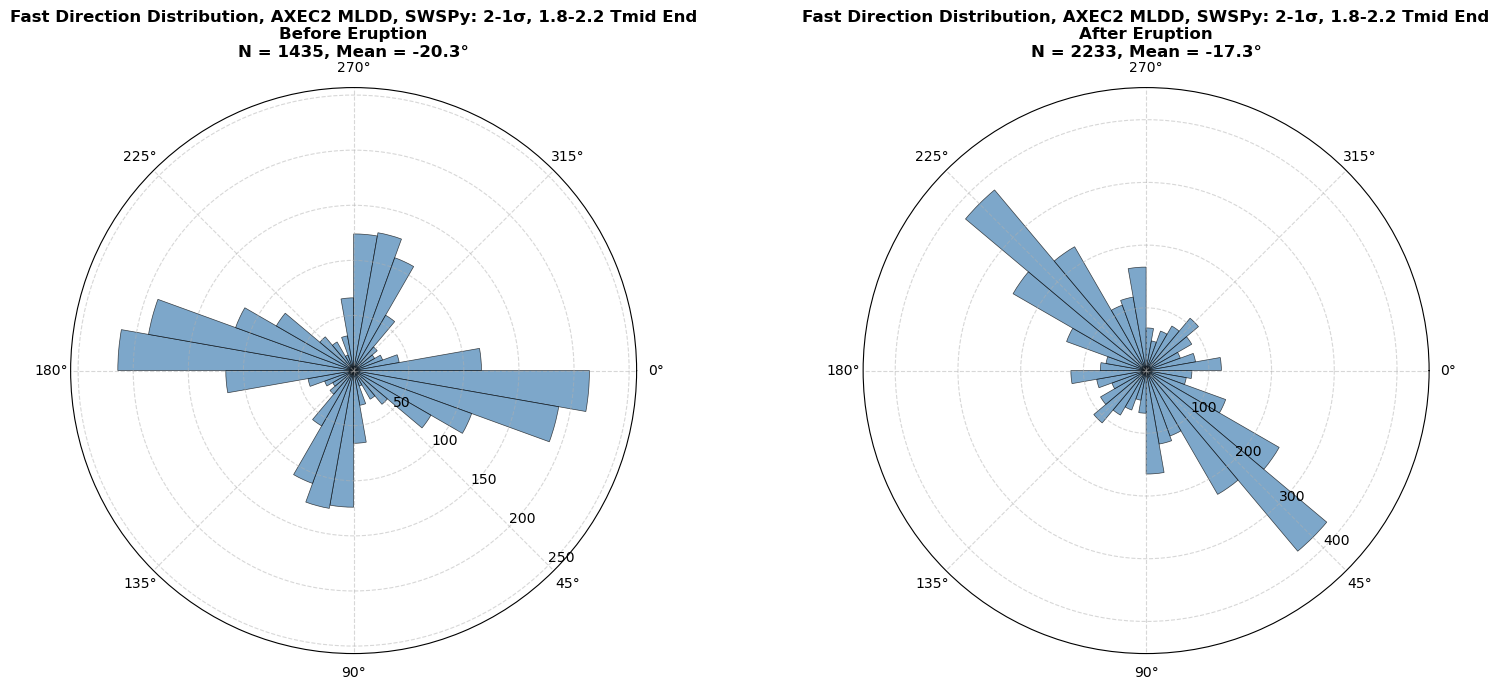

X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


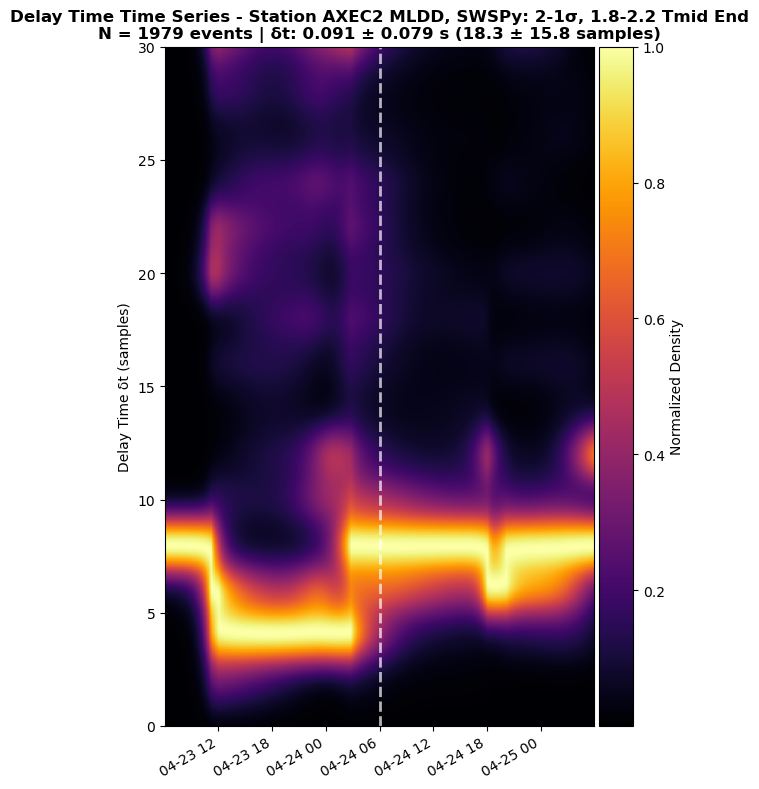

X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


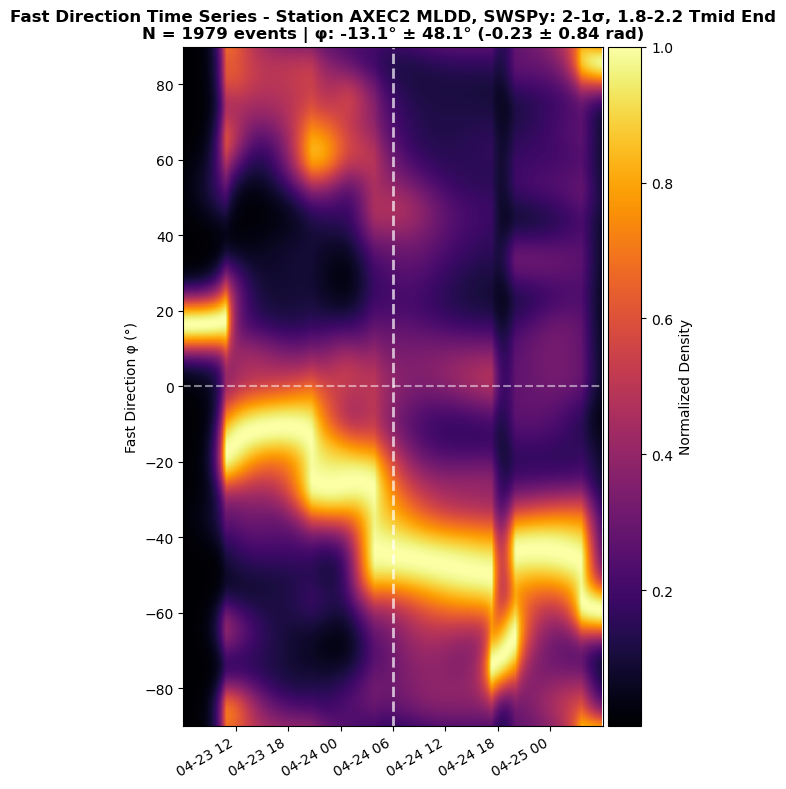

X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


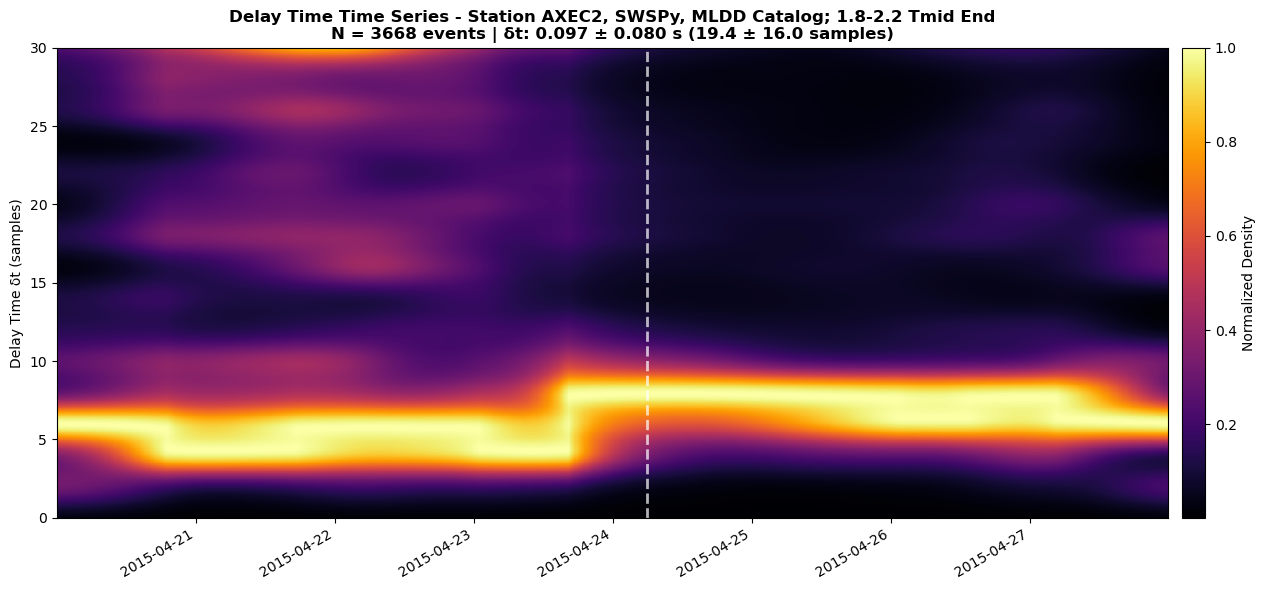

X is in UTCDateTime
Remember width should be given in seconds, otherwise memory error


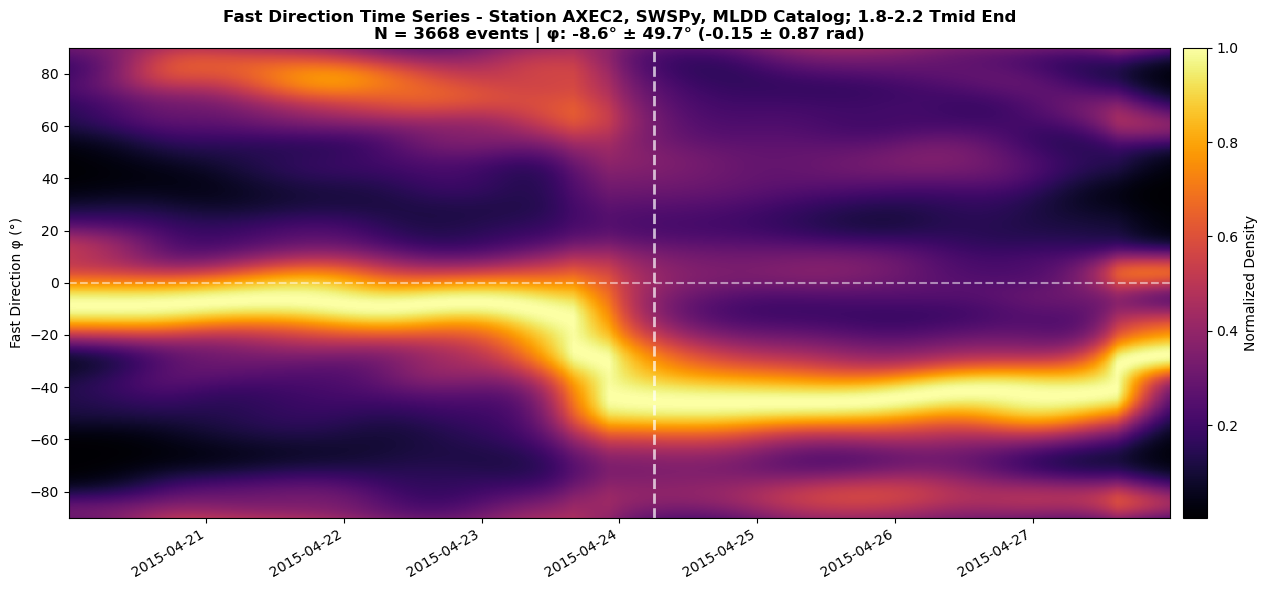

In [32]:
# AXEC2

results_mldd = pd.read_csv('../results/splitting_results_swspy_axec2_apr_20_28_mldd.csv')
# Drop dominant_period, first_window_start_pre_S_pick, last_window_start_pre_S_pick, first_window_end_post_S_pick, last_window_end_pre_S_pick, and all columns with "window" in their name
results_mldd = results_mldd.drop(['dominant_period', 'first_window_start_pre_S_pick', 'last_window_start_pre_S_pick', 'first_window_end_post_S_pick', 'last_window_end_post_S_pick'] + [col for col in results_mldd.columns if 'window' in col], axis=1)

results_mldd = results_mldd.dropna()

results_mldd.to_csv('../results/splitting_results_swspy_axec2_apr_20_28_mldd_cleaned.csv', index=False)

output_plots(filename='../results/splitting_results_swspy_axec2_apr_20_28_mldd_cleaned.csv',
             first_start = 2, last_start= 1, first_end=1.8, last_end=2.2, station='AXEC2 MLDD')

results_mldd['event_datetime'] = results_mldd['event_datetime'].apply(lambda x: UTCDateTime(x))

#starttime=UTCDateTime(2015, 4, 21, 0, 0, 0)
#endtime=UTCDateTime(2015, 4, 26, 0, 0)
#mask = (results_mldd['event_datetime'] >= starttime) & (results_mldd['event_datetime'] <= endtime)
#results_mldd = results_mldd[mask]

# Convert results_df_axas2 event_datetime to datetime for plotting
results_mldd['event_datetime'] = results_mldd['event_datetime'].apply(lambda x: x.datetime)

results_mldd_baillard_phi = results_mldd.copy()
# Conversion formula: phi_ccw_from_E = 90° - phi_cw_from_N
results_mldd_baillard_phi['phi'] = 90 - results_mldd_baillard_phi['phi']

# Handle wrapping: keep values in -90° to +90° range
# If result > 90°, subtract 180°
# If result < -90°, add 180°
results_mldd_baillard_phi['phi'] = results_mldd_baillard_phi['phi'].apply(
    lambda x: x - 180 if x > 90 else (x + 180 if x < -90 else x)
)


fig, ax = plot_dt_timeseries_movehisto(
    results_mldd_baillard_phi, 
    station='AXEC2, SWSPy, MLDD Catalog; 1.8-2.2 Tmid End',
    x_width=3600,  # 1 day time window (shorter)
    x_overlap=0.9,
    y_width=1,          # 1 sample bins (finer)
    y_overlap=0.9,
    flag_smooth=True,
    x_filter_per=5,     # Less smoothing in time (5%)
    y_filter_per=3      # Less smoothing in dt (5%)
)
plt.show()

fig, ax = plot_phi_timeseries_movehisto(
    results_mldd_baillard_phi, 
    station='AXEC2, SWSPy, MLDD Catalog; 1.8-2.2 Tmid End',
    x_width=3600,  # 1 day time window (shorter)
    x_overlap=0.9,
    y_width=5,          # 5 degree bins (finer)
    y_overlap=0.9,
    flag_smooth=True,
    x_filter_per=5,     # Less smoothing in time (5%)
    y_filter_per=3      # Less smoothing in phi (5%)
)
plt.show()